In [20]:
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore',category=UserWarning)

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [22]:
data=ImageDataGenerator(
    validation_split=0.2
)

In [23]:
train=data.flow_from_directory(
    './imgs',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)
test=data.flow_from_directory(
    './imgs',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

Found 2160 images belonging to 9 classes.
Found 540 images belonging to 9 classes.


In [24]:
class_names = list(train.class_indices.keys())
class_names

['兔子', '狗', '猪', '猫', '猴子', '老虎', '蛇', '马', '鸡']

In [25]:
from tensorflow.keras.applications import MobileNetV2

In [26]:
base_model=MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

In [27]:
base_model.trainable=False

In [28]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input,Rescaling,GlobalAveragePooling2D,Dense,Dropout

In [29]:
model=Sequential([
    Input(shape=(224,224,3)),
    Rescaling(scale=1./127.5,offset=-1),
    base_model,
    GlobalAveragePooling2D(),
    Dense(9,activation='softmax')
])

In [30]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

In [32]:
early_stopping=EarlyStopping(
    monitor='val_loss',
    patience=3,
    min_delta=0.0001,
    verbose=1,
    restore_best_weights=True
)

In [33]:
history=model.fit(
    train,
    validation_data=test,
    epochs=10,
    callbacks=early_stopping
)

Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 65s 845ms/step - accuracy: 0.7639 - loss: 0.8548 - val_accuracy: 0.8833 - val_loss: 0.4279
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 45s 659ms/step - accuracy: 0.9333 - loss: 0.2570 - val_accuracy: 0.8870 - val_loss: 0.3808
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 46s 676ms/step - accuracy: 0.9556 - loss: 0.1843 - val_accuracy: 0.9000 - val_loss: 0.3606
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 44s 648ms/step - accuracy: 0.9704 - loss: 0.1331 - val_accuracy: 0.8944 - val_loss: 0.3688
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 46s 675ms/step - accuracy: 0.9815 - loss: 0.1028 - val_accuracy: 0.9056 - val_loss: 0.3650
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 47s 689ms/step - accuracy: 0.9884 - loss: 0.0808 - val_accuracy: 0.9130 - val_loss: 0.3459
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 47s 695ms/step - accuracy: 0.9931 - loss: 0.0642 - val_accuracy: 0.9204 - val_loss: 0.3485
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 46s 681ms/step - accuracy: 0.9944 - loss: 0.0519 - val_accu

In [34]:
import matplotlib.pyplot as plt

In [35]:
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False

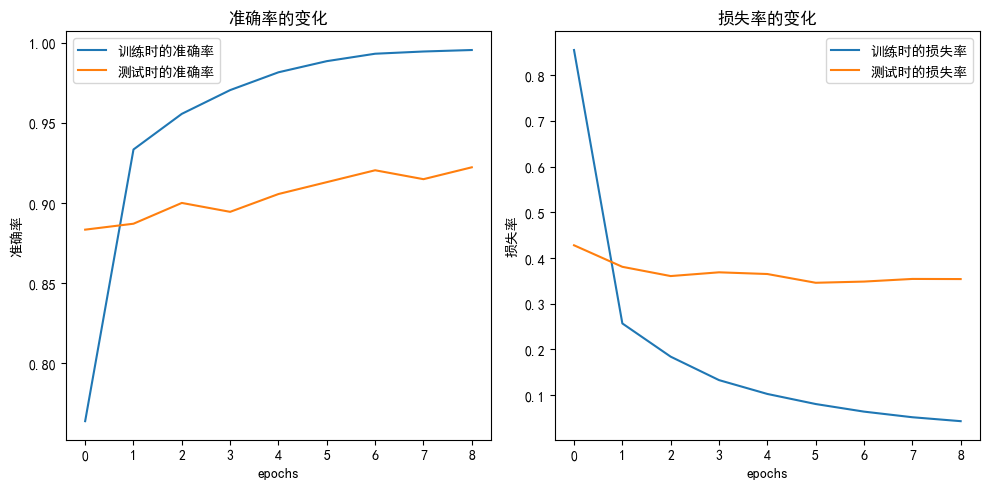

In [36]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='训练时的准确率')
plt.plot(history.history['val_accuracy'],label='测试时的准确率')
plt.legend()
plt.xlabel('epochs')
plt.ylabel('准确率')
plt.title('准确率的变化')

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='训练时的损失率')
plt.plot(history.history['val_loss'],label='测试时的损失率')
plt.legend()
plt.xlabel('epochs')
plt.ylabel('损失率')
plt.title('损失率的变化')

plt.tight_layout()
plt.savefig('result.png')

In [37]:
model.save('mobilenetv2-animal-classification.keras')